In [7]:
import dask
import numpy as np
import xarray as xr

In [1]:
import intake
cat = intake.open_catalog('https://digital-earths-global-hackathon.github.io/catalog/catalog.yaml')['online']
ds = cat['um_glm_n2560_RAL3p3'](zoom=10, time='PT3H', chunks='auto').to_dask()

/home/users/mmuetz/miniforge3/envs/hackathon_env/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)
/home/users/mmuetz/miniforge3/envs/hackathon_env/lib/python3.12/site-packages/intake_xarray/base.py:21: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  'dims': dict(self._ds.dims),


In [21]:
ds1.chunks

Frozen({'time': (1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [22]:
ds2.chunks

Frozen({})

In [32]:
import intake
cat = intake.open_catalog('https://raw.githubusercontent.com/digital-earths-global-hackathon/catalog/refs/heads/add-um-chunking/online/main.yaml')
print(xr.open_zarr(cat['um_glm_n2560_RAL3p3'](zoom=10, time='PT3H').urlpath)[['cli']])
print(cat['um_glm_n2560_RAL3p3'](zoom=10, time='PT3H').to_dask()[['cli']])

<xarray.Dataset> Size: 4TB
Dimensions:   (time: 3497, pressure: 25, cell: 12582912)
Coordinates:
  * cell      (cell) int64 101MB 0 1 2 3 ... 12582908 12582909 12582910 12582911
    crs       float64 8B ...
  * pressure  (pressure) int64 200B 1 5 10 20 30 50 ... 875 900 925 950 975 1000
  * time      (time) datetime64[ns] 28kB 2020-01-20 ... 2021-04-01
Data variables:
    cli       (time, pressure, cell) float32 4TB dask.array<chunksize=(1, 1, 1048576), meta=np.ndarray>
Attributes:
    Met Office DYAMOND3 simulations:  A group of experiments have been conduc...
    bounds:                           {'lower_left_lat': -90, 'lower_left_lon...
    latitiude_convention:             [-90, 90]
    longitude_convention:             [0, 360]
    regional:                         False
    simulation:                       glm.n2560_RAL3p3
    simulation_description:           The MetUM uses a regular lat-lon grid, ...
<xarray.Dataset> Size: 4TB
Dimensions:   (time: 3497, pressure: 25, cell: 12

/home/users/mmuetz/miniforge3/envs/hackathon_env/lib/python3.12/site-packages/intake_xarray/base.py:21: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  'dims': dict(self._ds.dims),


In [12]:
ds

<xarray.Dataset> Size: 53TB
Dimensions:   (cell: 12582912, time: 3497, pressure: 25)
Coordinates:
  * cell      (cell) int64 101MB 0 1 2 3 ... 12582908 12582909 12582910 12582911
    crs       float64 8B ...
  * pressure  (pressure) int64 200B 1 5 10 20 30 50 ... 875 900 925 950 975 1000
  * time      (time) datetime64[ns] 28kB 2020-01-20 ... 2021-04-01
Data variables:
    cli       (time, pressure, cell) float32 4TB dask.array<chunksize=(1, 1, 1048576), meta=np.ndarray>
    clw       (time, pressure, cell) float32 4TB dask.array<chunksize=(1, 1, 1048576), meta=np.ndarray>
    hur       (time, pressure, cell) float32 4TB dask.array<chunksize=(1, 1, 1048576), meta=np.ndarray>
    hus       (time, pressure, cell) float32 4TB dask.array<chunksize=(1, 1, 1048576), meta=np.ndarray>
    qg        (time, pressure, cell) float32 4TB dask.array<chunksize=(1, 1, 1048576), meta=np.ndarray>
    qr        (time, pressure, cell) float32 4TB dask.array<chunksize=(1, 1, 1048576), meta=np.ndarray>
    qs        (time, pressure, cell) float32 4TB dask.array<chunksize=(1, 1, 1048576), meta=np.ndarray>
    ta        (time, pressure, cell) float32 4TB dask.array<chunksize=(1, 1, 1048576), meta=np.ndarray>
    ua        (time, pressure, cell) float32 4TB dask.array<chunksize=(1, 1, 1048576), meta=np.ndarray>
    va        (time, pressure, cell) float32 4TB dask.array<chunksize=(1, 1, 1048576), meta=np.ndarray>
    wa        (time, pressure, cell) float32 4TB dask.array<chunksize=(1, 1, 1048576), meta=np.ndarray>
    zg        (time, pressure, cell) float32 4TB dask.array<chunksize=(1, 1, 1048576), meta=np.ndarray>
Attributes:
    Met Office DYAMOND3 simulations:  A group of experiments have been conduc...
    bounds:                           {'lower_left_lat': -90, 'lower_left_lon...
    latitiude_convention:             [-90, 90]
    longitude_convention:             [0, 360]
    regional:                         False
    simulation:                       glm.n2560_RAL3p3
    simulation_description:           The MetUM uses a regular lat-lon grid, ...

In [5]:
path = '/gws/nopw/j04/hrcm/mmuetz/tmp/'
store = path + 'um_glm_n2560_RAL3p3.PT3H.hp_z10.zarr'

In [4]:
ds_tpl = xr.Dataset()

In [5]:
for n, da in ds.data_vars.items():
    dummies = dask.array.zeros(da.shape, dtype=np.float32, chunks=(1, 1, 12 * 4**9))
    da_tpl = xr.DataArray(dummies, dims=da.dims, coords=da.coords, name=n, attrs=da.attrs)
    ds_tpl[n] = da_tpl

In [6]:
#ds_tpl.to_zarr(store, compute=False)

In [7]:
ds_sub = ds[['cli', 'clw', 'hus']].isel(time=slice(5)).drop_vars('crs')
print(ds_sub)
ds_sub.to_zarr(store, region='auto')

<xarray.Dataset> Size: 19GB
Dimensions:   (time: 5, pressure: 25, cell: 12582912)
Coordinates:
  * cell      (cell) int64 101MB 0 1 2 3 ... 12582908 12582909 12582910 12582911
  * pressure  (pressure) int64 200B 1 5 10 20 30 50 ... 875 900 925 950 975 1000
  * time      (time) datetime64[ns] 40B 2020-01-20 ... 2020-01-20T12:00:00
Data variables:
    cli       (time, pressure, cell) float32 6GB ...
    clw       (time, pressure, cell) float32 6GB ...
    hus       (time, pressure, cell) float32 6GB ...
Attributes:
    Met Office DYAMOND3 simulations:  A group of experiments have been conduc...
    bounds:                           {'lower_left_lat': -90, 'lower_left_lon...
    latitiude_convention:             [-90, 90]
    longitude_convention:             [0, 360]
    regional:                         False
    simulation:                       glm.n2560_RAL3p3
    simulation_description:           The MetUM uses a regular lat-lon grid, ...


In [8]:
ds_sub2 = xr.open_zarr(store)

In [9]:
ds_sub2

<xarray.Dataset> Size: 53TB
Dimensions:   (cell: 12582912, time: 3497, pressure: 25)
Coordinates:
  * cell      (cell) int64 101MB 0 1 2 3 ... 12582908 12582909 12582910 12582911
    crs       float64 8B ...
  * pressure  (pressure) int64 200B 1 5 10 20 30 50 ... 875 900 925 950 975 1000
  * time      (time) datetime64[ns] 28kB 2020-01-20 ... 2021-04-01
Data variables:
    cli       (time, pressure, cell) float32 4TB dask.array<chunksize=(1, 1, 3145728), meta=np.ndarray>
    clw       (time, pressure, cell) float32 4TB dask.array<chunksize=(1, 1, 3145728), meta=np.ndarray>
    hur       (time, pressure, cell) float32 4TB dask.array<chunksize=(1, 1, 3145728), meta=np.ndarray>
    hus       (time, pressure, cell) float32 4TB dask.array<chunksize=(1, 1, 3145728), meta=np.ndarray>
    qg        (time, pressure, cell) float32 4TB dask.array<chunksize=(1, 1, 3145728), meta=np.ndarray>
    qr        (time, pressure, cell) float32 4TB dask.array<chunksize=(1, 1, 3145728), meta=np.ndarray>
    qs        (time, pressure, cell) float32 4TB dask.array<chunksize=(1, 1, 3145728), meta=np.ndarray>
    ta        (time, pressure, cell) float32 4TB dask.array<chunksize=(1, 1, 3145728), meta=np.ndarray>
    ua        (time, pressure, cell) float32 4TB dask.array<chunksize=(1, 1, 3145728), meta=np.ndarray>
    va        (time, pressure, cell) float32 4TB dask.array<chunksize=(1, 1, 3145728), meta=np.ndarray>
    wa        (time, pressure, cell) float32 4TB dask.array<chunksize=(1, 1, 3145728), meta=np.ndarray>
    zg        (time, pressure, cell) float32 4TB dask.array<chunksize=(1, 1, 3145728), meta=np.ndarray>

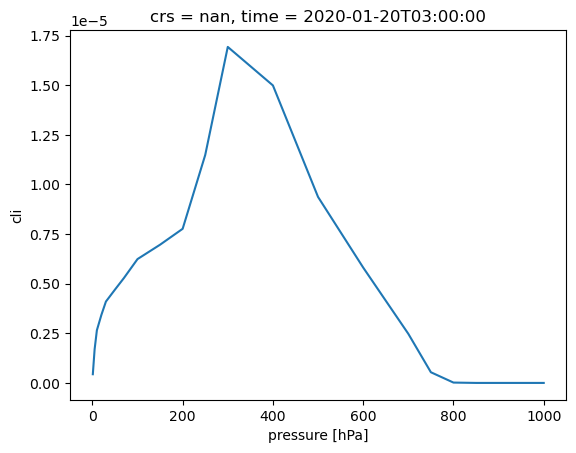

In [23]:
ds_sub2.cli.isel(time=1).mean(dim='cell').plot()

In [31]:
da = ds_sub2.cli
da_flipped = xr.DataArray(da.data[::-1], name=da.name, dims=da.dims, coords=da.coords, attrs=da.attrs).drop_vars('crs')
comp = da_flipped.isel(time=slice(5)).to_zarr(store, compute=False, region='auto')
comp.compute()

In [8]:
for i in range(5):
    print(i)
    ds_sub = ds[['cli', 'clw', 'qg', 'qr', 'qs']].isel(time=slice(i, i + 1))
    for n, da in ds_sub.data_vars.items():
        print(f'  {n}')
        dac = da.compute()
        da_flipped = xr.DataArray(dac.values[::-1], name=da.name, dims=da.dims, coords=da.coords, attrs=da.attrs).drop_vars('crs')
        da_flipped.to_zarr(store, region='auto')

0
  cli
  clw
  qg
  qr
  qs
1
  cli
  clw
  qg
  qr
  qs
2
  cli
  clw
  qg
  qr
  qs
3
  cli
  clw
  qg
  qr
  qs
4
  cli
  clw
  qg
  qr
  qs


In [3]:
print(dsc)

<xarray.Dataset> Size: 6GB
Dimensions:   (time: 1, pressure: 25, cell: 12582912)
Coordinates:
  * cell      (cell) int64 101MB 0 1 2 3 ... 12582908 12582909 12582910 12582911
    crs       float64 8B nan
  * pressure  (pressure) int64 200B 1 5 10 20 30 50 ... 875 900 925 950 975 1000
  * time      (time) datetime64[ns] 8B 2020-01-20
Data variables:
    cli       (time, pressure, cell) float32 1GB nan nan nan nan ... nan nan nan
    clw       (time, pressure, cell) float32 1GB nan nan nan nan ... nan nan nan
    qg        (time, pressure, cell) float32 1GB nan nan nan nan ... nan nan nan
    qr        (time, pressure, cell) float32 1GB nan nan nan nan ... nan nan nan
    qs        (time, pressure, cell) float32 1GB nan nan nan nan ... nan nan nan
Attributes:
    Met Office DYAMOND3 simulations:  A group of experiments have been conduc...
    bounds:                           {'lower_left_lat': -90, 'lower_left_lon...
    latitiude_convention:             [-90, 90]
    longitude_conventi

In [4]:
del dsc

In [39]:
import gc

In [40]:
gc.collect(2)

5958702